In [1]:
import os
import cv2
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torchvision
from torchvision import transforms
from src.models.train import QualityDescriptor

In [2]:
system = QualityDescriptor.load_from_checkpoint('/mnt/QUANTGEN/SRCDATA/DL/Faxitron/checkpoints/pepper/SQP_pepper/SGD/cp_epoch=340_val_loss=0.418_val_F1=0.837.ckpt')

model = system.model

In [3]:
model.freeze()

In [4]:
# Image Path
path = '/mnt/QUANTGEN/SRCDATA/DL/Faxitron/datasets/images/pepper/'
test_img_name = '5c1204ea22ddb32f7cef8f0a_30.jpg'

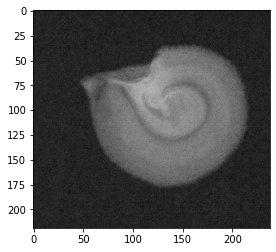

In [5]:
img_origin = Image.open(path+test_img_name)
plt.imshow(img_origin)
plt.show()

In [6]:
df = pd.read_csv('datasets/labels/pepper/labels.csv')
df.head()

,Unnamed: 0,filename,label
0,0,5c4ef33d22ddb30e00052879_0.jpg,geen prime
1,1,5c4ef33d22ddb30e00052879_1.jpg,geen prime
2,2,5c4ef33d22ddb30e00052879_2.jpg,geen prime
3,3,5c4ef33d22ddb30e00052879_3.jpg,geen prime
4,4,5c4ef33d22ddb30e00052879_4.jpg,geen prime


In [7]:
def actual_label(jpg_file):
    '''put jpg_file name then returns the actual label of the image
       jpg_file should be string format'''
    
    img_label = df.loc[df['filename'] == jpg_file, 'label'].iloc[0]
    return img_label

In [8]:
actual_label(test_img_name)

'prime'

In [9]:
def transform(original_x, shape=224):
    
    transform = transforms.Compose([
    transforms.Resize(shape),
    transforms.CenterCrop(shape),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.1717, 0.1717, 0.1717],
                         std=[0.0773, 0.0773, 0.0773]),
    ])
    
    transformed_x = transform(original_x).unsqueeze(0)
    
    return transformed_x

In [10]:
x = transform(img_origin)
x.shape

torch.Size([1, 3, 224, 224])

In [11]:
pred = model(x)
pred

tensor([[-2.2582, -0.4706, -0.2529,  2.8084,  0.3241]])

In [12]:
# "class_id" info is in seedqualitypredictor.src.data.stats.py file 

LABEL_TO_CLASS = {0: "abnormaal",
                  1: "geen prime",
                  2: "licht prime",
                  3: "prime",
                  4: "voorkiem"}

In [13]:
def predict_class(transformed_x):
    """put transformed_x then returns the predicted class
       trnasformed_x should be resized, normalized and is in a 
       tensor format"""
    pred = model(transformed_x)
    probs = torch.softmax(pred.detach().cpu(), dim=1).numpy()
    probs = np.argmax(probs, axis=1)
    pred_class = probs[0]
    
    return pred_class

In [14]:
pred_index = predict_class(x)
pred_index

3

In [15]:
LABEL_TO_CLASS[predict_class(x)]

'prime'

In [33]:
resize = transforms.Resize((224,224))
resized = resize(img_origin)
re = np.array(resized)
re.shape

(224, 224, 3)

# Captum Intergrated Gradients (Gradient)

In [16]:
from captum.attr import IntegratedGradients
from captum.attr import visualization as viz

ig = IntegratedGradients(model)

In [35]:
attr_ig, approximation_error = ig.attribute(x,
                                            baselines = x * 0,
                                            target = int(pred_index),
                                            n_steps=50,
                                            return_convergence_delta = True)

In [36]:
print('approximation_error (aka convergence delta):', approximation_error)

approximation_error (aka convergence delta): tensor([-1.3538])


In [37]:
attr_ig.shape

torch.Size([1, 3, 224, 224])

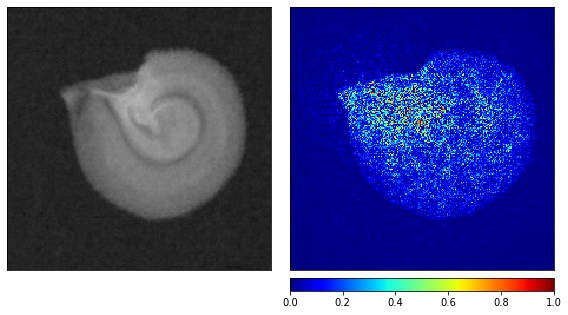

In [38]:
# visualizing the image and corresponding attributions 
# by overlaying the latter on the image.

_ = viz.visualize_image_attr_multiple(np.transpose(attr_ig.squeeze().cpu().detach().numpy(), (1,2,0)),
                             re,
                             ["original_image", "heat_map"],
                             ["all", "absolute_value"],
                             cmap='jet',
                             show_colorbar=True)

In [41]:
from matplotlib.colors import LinearSegmentedColormap
default_cmap = LinearSegmentedColormap.from_list('custom blue', 
                                                 [(0, '#ffffff'),
                                                  (0.25, '#000000'),
                                                  (1, '#000000')])

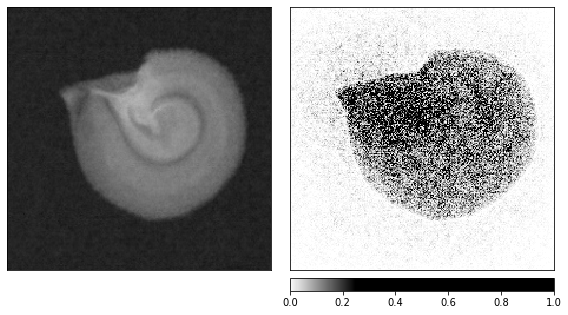

In [43]:
# visualizing the image and corresponding attributions 
# by overlaying the latter on the image.

_ = viz.visualize_image_attr_multiple(np.transpose(attr_ig.squeeze().cpu().detach().numpy(), (1,2,0)),
                             re,
                             ["original_image", "heat_map"],
                             ["all", "absolute_value"],
                             cmap=default_cmap,
                             show_colorbar=True)

# Captum Gradient SHAP (Gradient)

In [44]:
from captum.attr import GradientShap

gradient_shap = GradientShap(model)

# Defining baseline distribution of images
rand_img_dist = torch.cat([x * 0, x * 1])

In [46]:
attr_gradSHAP = gradient_shap.attribute(x,
                                        baselines=rand_img_dist,
                                        n_samples=50,
                                        stdevs=0.09,
                                        target = int(pred_index))

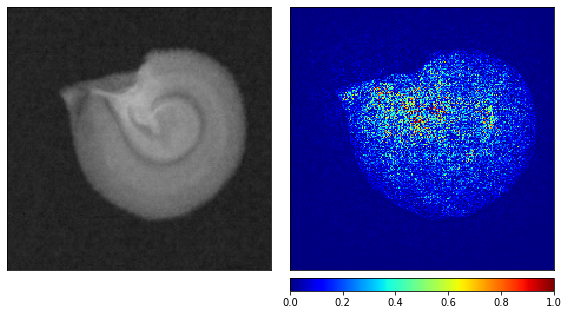

In [48]:
_ = viz.visualize_image_attr_multiple(np.transpose(attr_gradSHAP.squeeze().cpu().detach().numpy(), (1,2,0)),
                                      re,
                                      ["original_image", "heat_map"],
                                      ["all",  "absolute_value"],
                                      cmap='jet',
                                      show_colorbar=True)

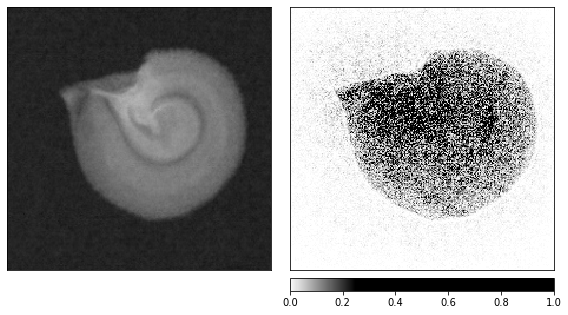

In [49]:
fig, axis = viz.visualize_image_attr_multiple(np.transpose(attr_gradSHAP.squeeze().cpu().detach().numpy(), (1,2,0)),
                                            re,
                                            ["original_image", "heat_map"],
                                            ["all", "absolute_value"],
                                            cmap=default_cmap,
                                            show_colorbar=True)
                            

# Captum Noise Tunnel with GradientsSHAP 

In [51]:
from captum.attr import NoiseTunnel

noise_tunnel_shap = NoiseTunnel(gradient_shap)

attr_shap_nt = noise_tunnel_shap.attribute(x,
                                           n_samples=5,
                                           baselines=0*x,
                                           target = int(pred_index),
                                           nt_type='smoothgrad')

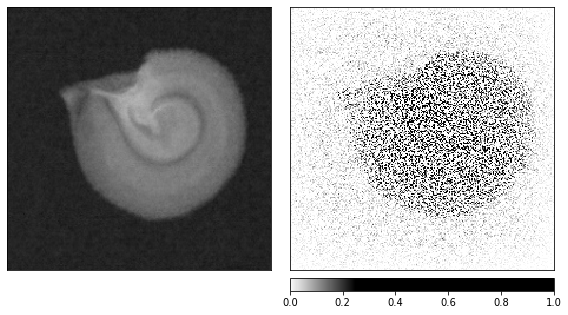

In [54]:
_ = viz.visualize_image_attr_multiple(np.transpose(attr_shap_nt.squeeze().cpu().detach().numpy(), (1,2,0)),
                                      re,
                                      ["original_image", "heat_map"],
                                      ["all", "positive"],
                                      cmap=default_cmap,
                                      show_colorbar=True)

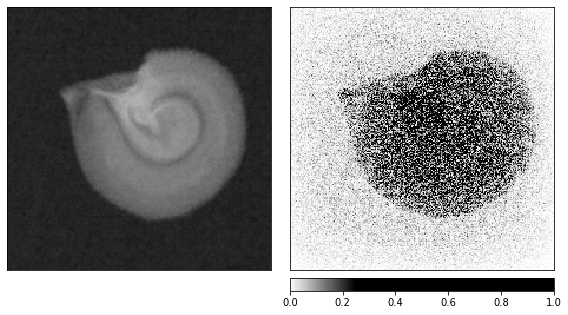

In [55]:
_ = viz.visualize_image_attr_multiple(np.transpose(attr_shap_nt.squeeze().cpu().detach().numpy(), (1,2,0)),
                                      re,
                                      ["original_image", "heat_map"],
                                      ["all", "absolute_value"],
                                      cmap=default_cmap,
                                      show_colorbar=True)

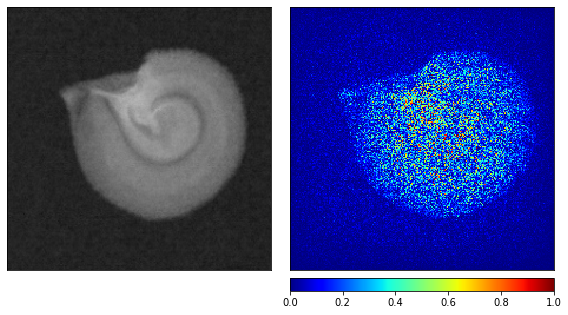

In [56]:
_ = viz.visualize_image_attr_multiple(np.transpose(attr_shap_nt.squeeze().cpu().detach().numpy(), (1,2,0)),
                                      re,
                                      ["original_image", "heat_map"],
                                      ["all", "absolute_value"],
                                      cmap='jet',
                                      show_colorbar=True)

# Layer Conductance (Layer)

In [58]:
from captum.attr import LayerConductance

lc = LayerConductance(model, model.encoder.layer2)
attr_lc = lc.attribute(x,target = int(pred_index))

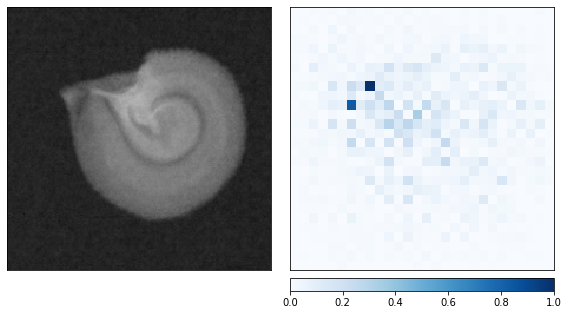

In [59]:
_ = viz.visualize_image_attr_multiple(np.transpose(attr_lc.squeeze().cpu().detach().numpy(), (1,2,0)),
                                      re,
                                      ["original_image", "heat_map"],
                                      ["all", "absolute_value"],
                                      show_colorbar=True,
                                      outlier_perc=2)

In [60]:
lc = LayerConductance(model, model.encoder.layer1)
attr_lc = lc.attribute(x,target = int(pred_index))

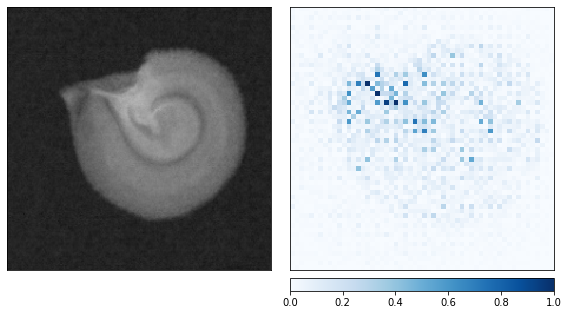

In [61]:
_ = viz.visualize_image_attr_multiple(np.transpose(attr_lc.squeeze().cpu().detach().numpy(), (1,2,0)),
                                      re,
                                      ["original_image", "heat_map"],
                                      ["all", "absolute_value"],
                                      show_colorbar=True,
                                      outlier_perc=2)

In [62]:
lc = LayerConductance(model, model.encoder.layer0)
attr_lc = lc.attribute(x,target = int(pred_index))

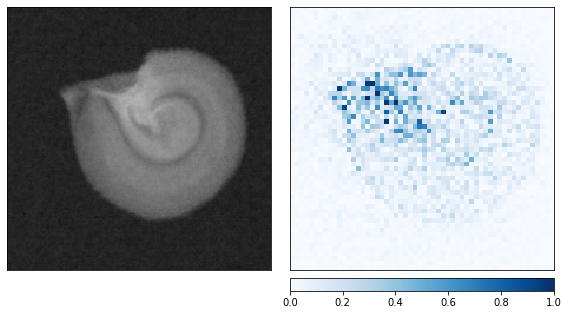

In [63]:
_ = viz.visualize_image_attr_multiple(np.transpose(attr_lc.squeeze().cpu().detach().numpy(), (1,2,0)),
                                      re,
                                      ["original_image", "heat_map"],
                                      ["all", "absolute_value"],
                                      show_colorbar=True,
                                      outlier_perc=2)

# Layer Gradient X Activation

In [64]:
from captum.attr import LayerGradientXActivation

layer_ga = LayerGradientXActivation(model, model.encoder.layer0)
attr_layer_gxa = layer_ga.attribute(x,target = int(pred_index))

/home/SOKI/ImageFiles/xray_seed/lib/python3.6/site-packages/captum/attr/_utils/gradient.py:33: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  "required_grads has been set automatically." % index


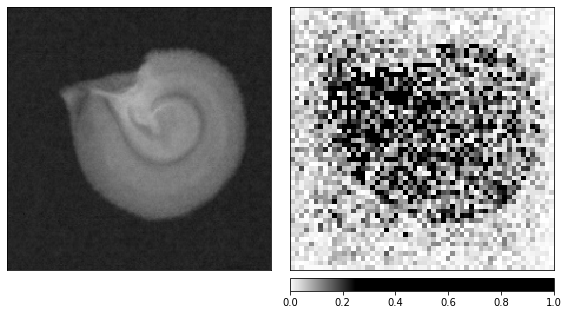

In [66]:
_ = viz.visualize_image_attr_multiple(np.transpose(attr_layer_gxa.squeeze().cpu().detach().numpy(), (1,2,0)),
                                      re,
                                      ["original_image", "heat_map"],
                                      ["all", "absolute_value"],
                                      cmap=default_cmap,
                                      show_colorbar=True,
                                      outlier_perc=2)

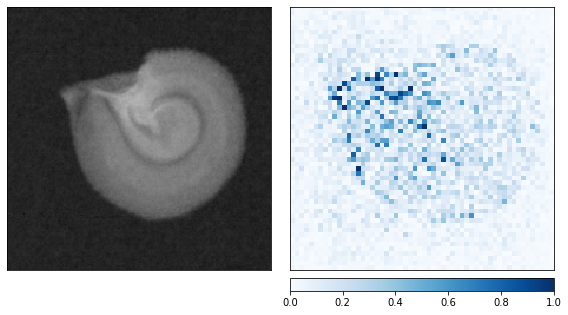

In [69]:
_ = viz.visualize_image_attr_multiple(np.transpose(attr_layer_gxa.squeeze().cpu().detach().numpy(), (1,2,0)),
                                      re,
                                      ["original_image", "heat_map"],
                                      ["all", "absolute_value"],
                                      show_colorbar=True,
                                      outlier_perc=2)

In [70]:
layer_ga = LayerGradientXActivation(model, model.encoder.layer1)
attr_layer_gxa = layer_ga.attribute(x,target = int(pred_index))

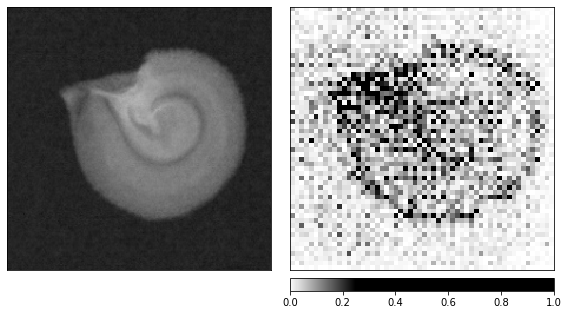

In [71]:
_ = viz.visualize_image_attr_multiple(np.transpose(attr_layer_gxa.squeeze().cpu().detach().numpy(), (1,2,0)),
                                      re,
                                      ["original_image", "heat_map"],
                                      ["all", "absolute_value"],
                                      cmap=default_cmap,
                                      show_colorbar=True,
                                      outlier_perc=2)

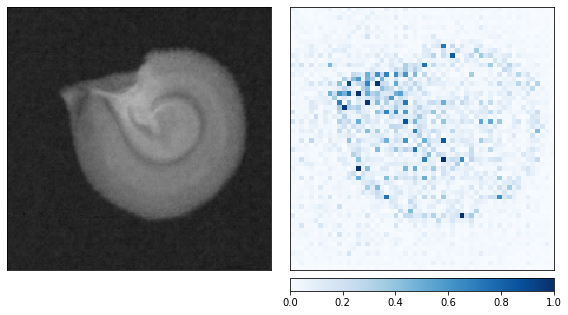

In [72]:
_ = viz.visualize_image_attr_multiple(np.transpose(attr_layer_gxa.squeeze().cpu().detach().numpy(), (1,2,0)),
                                      re,
                                      ["original_image", "heat_map"],
                                      ["all", "absolute_value"],
                                      show_colorbar=True,
                                      outlier_perc=2)

In [73]:
layer_ga = LayerGradientXActivation(model, model.encoder.layer2)
attr_layer_gxa = layer_ga.attribute(x,target = int(pred_index))

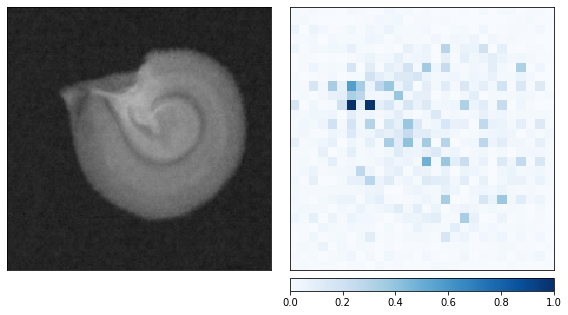

In [74]:
_ = viz.visualize_image_attr_multiple(np.transpose(attr_layer_gxa.squeeze().cpu().detach().numpy(), (1,2,0)),
                                      re,
                                      ["original_image", "heat_map"],
                                      ["all", "absolute_value"],
                                      show_colorbar=True,
                                      outlier_perc=2)

In [75]:
layer_ga = LayerGradientXActivation(model, model.encoder.layer3)
attr_layer_gxa = layer_ga.attribute(x,target = int(pred_index))

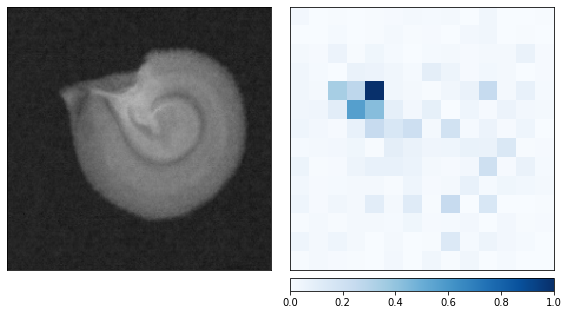

In [76]:
_ = viz.visualize_image_attr_multiple(np.transpose(attr_layer_gxa.squeeze().cpu().detach().numpy(), (1,2,0)),
                                      re,
                                      ["original_image", "heat_map"],
                                      ["all", "absolute_value"],
                                      show_colorbar=True,
                                      outlier_perc=2)

In [77]:
layer_ga = LayerGradientXActivation(model, model.encoder.layer4)
attr_layer_gxa = layer_ga.attribute(x,target = int(pred_index))

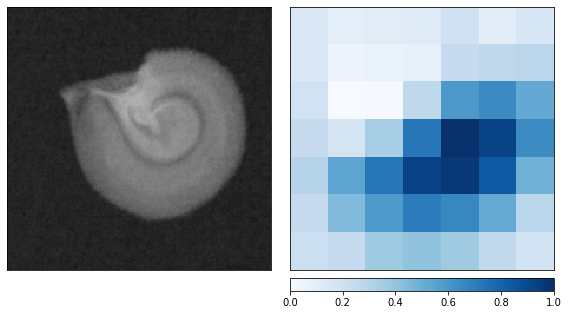

In [78]:
_ = viz.visualize_image_attr_multiple(np.transpose(attr_layer_gxa.squeeze().cpu().detach().numpy(), (1,2,0)),
                                      re,
                                      ["original_image", "heat_map"],
                                      ["all", "absolute_value"],
                                      show_colorbar=True,
                                      outlier_perc=2)